In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


Print the shape of the DataFrame (number of rows and columns).
Display the data types of all columns.
Count the number of missing values in each column.
Calculate the percentage of missing values for each column, rounded to 2 decimal places.
Hint: Percentage = (missing count / total rows) * 100

In [2]:
print(df.shape)
print(df.info())
print(df.isna().sum())
missing_count = df.isnull()
percentage = round(missing_count.mean()*100,2)
print("\n")
print(percentage)


(200, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       200 non-null    int64  
 1   city           200 non-null    object 
 2   category       200 non-null    object 
 3   order_value    186 non-null    float64
 4   delivery_days  190 non-null    float64
 5   rating         168 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 9.5+ KB
None
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64


order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


Use df.describe() to generate a summary of all numerical columns. In a markdown cell below the output, write two observations from the summary (for example: which column has the highest mean, or which column shows a large gap between its max and 75th percentile).
Plot a histogram for the order_value column to visualize its distribution.
Plot a box plot for the delivery_days column to inspect for outliers.
Make sure every plot has a title and axis labels.

In [3]:
print(df.describe())

          order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000


the column order_value has greatest mean value 
and the column order_value has the highest difference  etewwn max and 75 percentile 

Text(0.5, 1.0, 'histogram of orderValue')

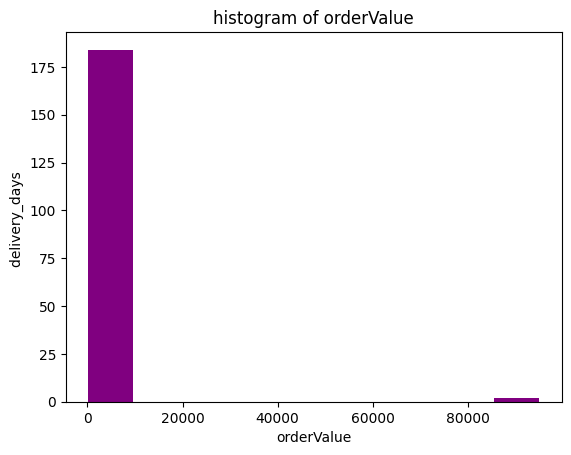

In [4]:
import matplotlib.pyplot as plt
# print(df.head(10))
plt.hist(df["order_value"], color="purple")
plt.xlabel("orderValue")
plt.ylabel("delivery_days ")
plt.title("histogram of orderValue")

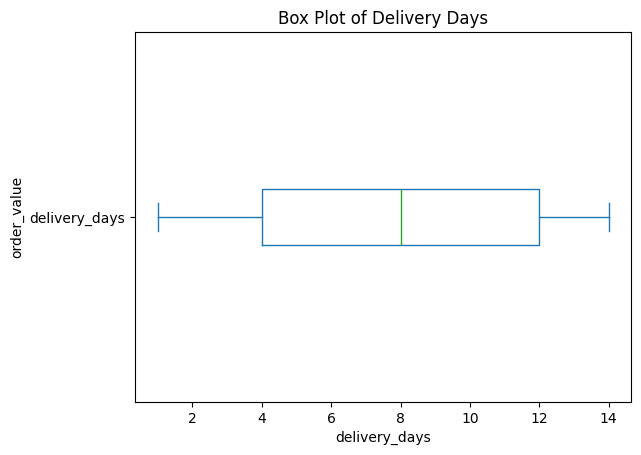

In [5]:
import matplotlib.pyplot as plt
df['delivery_days'].plot(kind='box', vert=False)
plt.title('Box Plot of Delivery Days')
plt.xlabel('delivery_days')
plt.ylabel("order_value")
plt.show()

Compute the correlation matrix for all numerical columns using df.corr().
Plot a heatmap of the correlation matrix with annotation values visible inside each cell.
In a markdown cell, write one observation from the heatmap — identify any two columns that appear to have a notable positive or negative relationship.

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


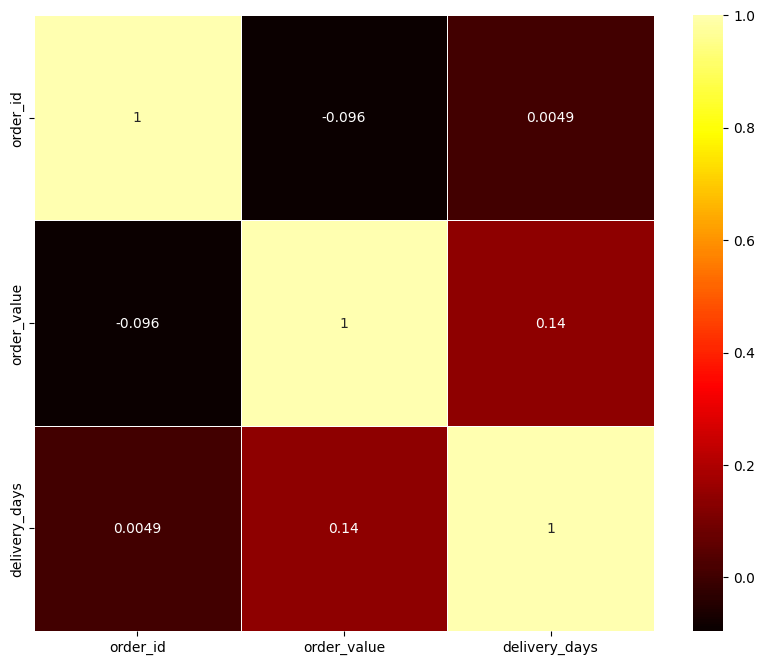

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
matrix = df.corr(numeric_only=True)
print(matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot = True,linewidths=0.5,cmap="hot",center=0.5)
plt.show()


ordervalue and delicery days(1.49) have a strong positive relation
orderid & ordervalue (-0.096): This shows a very weak negative relationship
